In [16]:
# Aplicando MP a un caso real

# Leer los datos 'load_breast_cancer'
from sklearn.datasets import load_breast_cancer
breast_cancer = load_breast_cancer()


In [17]:
dir(breast_cancer)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [18]:
X=breast_cancer.data
y=breast_cancer.target

In [19]:
X[0]

array([1.799e+01, 1.038e+01, 1.228e+02, 1.001e+03, 1.184e-01, 2.776e-01,
       3.001e-01, 1.471e-01, 2.419e-01, 7.871e-02, 1.095e+00, 9.053e-01,
       8.589e+00, 1.534e+02, 6.399e-03, 4.904e-02, 5.373e-02, 1.587e-02,
       3.003e-02, 6.193e-03, 2.538e+01, 1.733e+01, 1.846e+02, 2.019e+03,
       1.622e-01, 6.656e-01, 7.119e-01, 2.654e-01, 4.601e-01, 1.189e-01])

In [20]:
y[0]

np.int64(0)

In [21]:
X.shape

(569, 30)

In [22]:
y.shape

(569,)

In [23]:
# Visualizamos
import pandas as pd

df=pd.DataFrame(X,columns=breast_cancer.feature_names)
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [24]:
# 3. Dividirlo
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df, y, test_size=0.2, random_state=42)

In [25]:
X_train.shape

(455, 30)

In [26]:
y_train.shape

(455,)

In [33]:
# Implementar nuestra neurona MP

import numpy as np
from sklearn.metrics import accuracy_score

class MPNeuron:
  def __init__(self):
    self.threshold = None

  def model(self, x):
    # input:[1,0,0,0] [x1,x2,x3,...,xn]
    z = sum(x)
    return(z >= self.threshold)

  def predict(self, X):
    # input [[1,0,1,0], [1,0,1,1]]
    Y = []
    for x in X:
      Y.append(self.model(x))
    return np.array(Y)

  def fit(self, X, Y):
        accuracy = {}
        # Seleccionamos un threshold entre el # de características de entrada
        for th in range(X.shape[1] + 1):
            self.threshold = th
            Y_pred = self.predict(X)
            accuracy[th] = accuracy_score(Y_pred, Y)
        # Seleccionamos el threshold que mejores resultados proporciona
        self.threshold = max(accuracy, key=accuracy.get)

[1, 1, 0, 0, 0, 1, 1]
Categories (2, int64): [1 < 0]


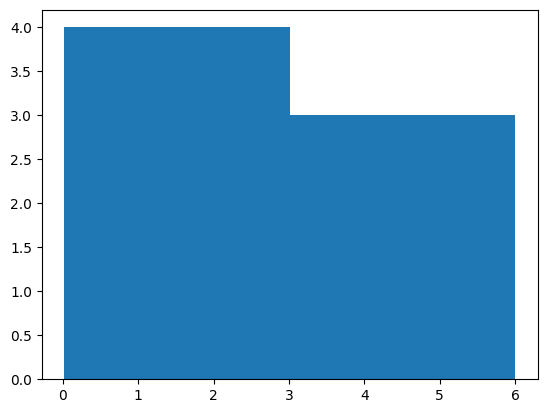

In [34]:
#

import matplotlib.pyplot as plt

print(pd.cut([0.04, 2, 4, 5, 6, 0.02, 0.6], bins=2, labels=[1, 0]))

plt.hist([0.04, 0.3, 4, 5, 6, 0.02, 0.6], bins=2)
plt.show()

In [35]:
X_train_bin = X_train.apply(pd.cut, bins=2, labels=[1, 0])
X_test_bin = X_test.apply(pd.cut, bins=2, labels=[1, 0])

In [36]:
X_train_bin

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
68,1,1,1,1,1,1,0,1,0,0,...,1,1,1,1,0,1,0,0,0,0
181,0,0,0,1,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
63,1,1,1,1,1,1,1,1,0,1,...,1,1,1,1,1,1,1,1,1,1
248,1,0,1,1,1,1,1,1,1,1,...,1,0,1,1,0,1,1,1,1,1
60,1,1,1,1,0,1,1,1,0,1,...,1,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,1,1,1,1,1,1,1,1,1,0,...,1,1,1,1,1,1,1,1,1,1
106,1,1,1,1,0,1,1,1,1,1,...,1,1,1,1,0,1,1,1,1,1
270,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
435,1,1,1,1,1,1,1,1,1,1,...,1,0,1,1,0,1,1,0,1,1


In [37]:
# Vamos a Jugar - Instanciamos

mp_neuron = MPNeuron()
mp_neuron.fit(X_train_bin.values, y_train)

In [38]:
mp_neuron.threshold

28

In [39]:
y_pred = mp_neuron.predict(X_test_bin.values)

In [40]:
y_pred

array([ True, False,  True, False, False, False, False, False, False,
        True,  True, False,  True, False,  True, False,  True,  True,
       False, False,  True,  True, False,  True,  True, False,  True,
       False,  True, False,  True,  True, False,  True,  True,  True,
        True,  True, False,  True,  True, False,  True,  True, False,
        True, False, False,  True, False, False, False, False, False,
       False,  True, False, False,  True,  True,  True, False, False,
        True,  True,  True, False, False,  True,  True, False, False,
        True, False, False,  True,  True,  True,  True, False, False,
        True, False, False, False, False, False, False, False,  True,
        True, False,  True, False,  True, False, False, False,  True,
       False,  True,  True, False, False,  True,  True, False, False,
        True,  True, False,  True, False, False])

In [41]:
accuracy_score(y_test, y_pred)

0.7456140350877193

In [42]:
y_test[0]

np.int64(1)

In [43]:
y_pred[0] # Ha acertado

np.True_